# Day 14: Food Delivery Data Visualization Portfolio

This portfolio uses Matplotlib and Seaborn to explore food-delivery orders, revenue, customer experience, marketing, cities, cuisines, weather, and order channels. Each visual is paired with a data-driven interpretation.

## Objectives

- Examine order and revenue patterns over time.
- Compare performance across cities, cuisines, weather conditions, and channels.
- Investigate marketing efficiency and customer-experience relationships.
- Summarize the most actionable findings.

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

source_path = Path(r'c:\Users\HP\Searches\Internship\Day14_Food_Delivery_Visualization_Dataset.csv')
df = pd.read_csv(source_path, parse_dates=['Date'])
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
df = df.sort_values('Date').reset_index(drop=True)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold', 'axes.titlesize': 13})

print(f'Rows: {df.shape[0]}, columns: {df.shape[1]}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Total missing values: {int(df.isna().sum().sum())}')
display(df.head())
display(df[['Orders', 'Revenue', 'Marketing_Spend', 'Avg_Delivery_Minutes', 'Customer_Rating']].describe().round(2))

Rows: 360, columns: 16
Duplicate rows: 0
Total missing values: 0


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0144,2025-01-02,January,Thursday,Mumbai,Biryani,Website,Rainy,153,417.10,60737.12,23547.30,3265.59,39.1,4.14,36.8
1,FD0275,2025-01-03,January,Friday,Kochi,Chinese,App,Hot,116,380.72,39270.56,18855.32,3746.66,30.5,4.55,44.7
2,FD0255,2025-01-03,January,Friday,Delhi,Biryani,Website,Clear,142,439.59,70923.09,16235.11,4103.07,36.7,4.32,32.0
3,FD0036,2025-01-04,January,Saturday,Kochi,Chinese,App,Hot,116,360.82,44866.11,15073.06,3266.97,27.2,4.57,43.9
4,FD0263,2025-01-05,January,Sunday,Kochi,North Indian,Website,Cloudy,117,419.96,48166.96,17316.98,4452.69,31.6,4.57,42.1


,Orders,Revenue,Marketing_Spend,Avg_Delivery_Minutes,Customer_Rating
count,360.00,360.00,360.00,360.00,360.00
mean,147.65,60591.11,27161.43,32.58,4.45
std,33.39,17387.93,6970.56,5.28,0.21
min,58.00,20618.53,11336.64,20.60,3.81
25%,123.75,48400.83,21822.50,28.68,4.31
50%,147.00,58779.19,25874.14,32.00,4.47
75%,169.00,71740.14,32387.14,35.95,4.61
max,235.00,121381.98,45000.00,50.10,4.94


## 1. Monthly orders and revenue trend

A dual-axis line chart shows whether volume and revenue move together across the year.

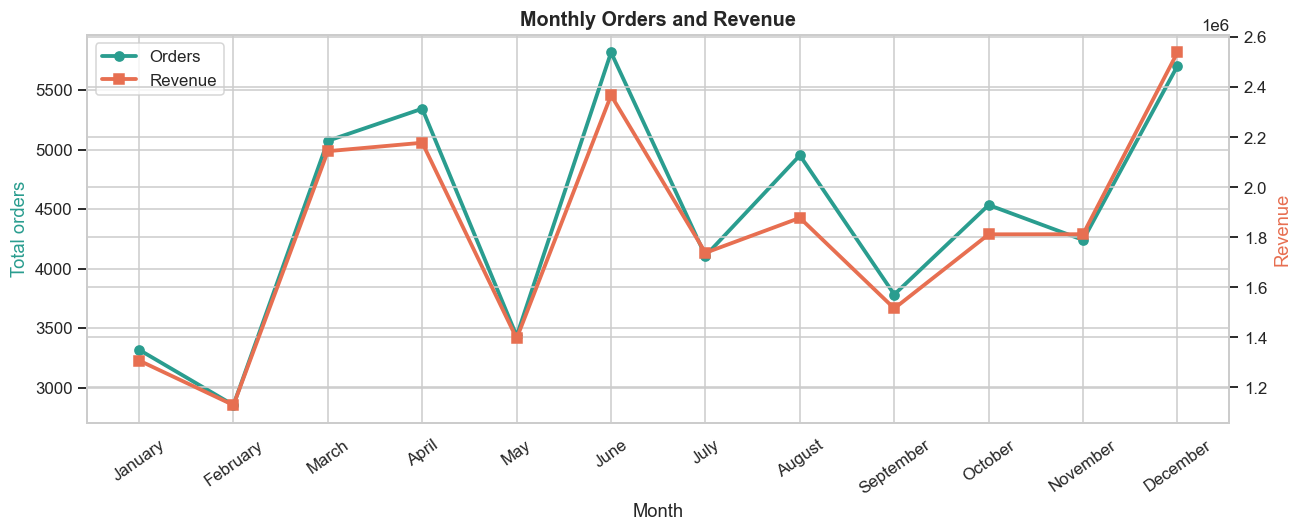

Interpretation: June has the highest order volume (5,816 orders), while December generates the highest revenue (2,538,435).


In [14]:
monthly = df.groupby('Month', observed=False)[['Orders', 'Revenue']].sum().reindex(month_order)
fig, order_axis = plt.subplots(figsize=(12, 5))
revenue_axis = order_axis.twinx()
order_axis.plot(monthly.index, monthly['Orders'], marker='o', linewidth=2.5, color='#2a9d8f', label='Orders')
revenue_axis.plot(monthly.index, monthly['Revenue'], marker='s', linewidth=2.5, color='#e76f51', label='Revenue')
order_axis.set_title('Monthly Orders and Revenue')
order_axis.set_xlabel('Month')
order_axis.set_ylabel('Total orders', color='#2a9d8f')
revenue_axis.set_ylabel('Revenue', color='#e76f51')
order_axis.tick_params(axis='x', rotation=35)
lines = order_axis.get_lines() + revenue_axis.get_lines()
order_axis.legend(lines, [line.get_label() for line in lines], loc='upper left')
fig.tight_layout()
plt.show()
peak_orders_month = monthly['Orders'].idxmax()
peak_revenue_month = monthly['Revenue'].idxmax()
print(f'Interpretation: {peak_orders_month} has the highest order volume ({monthly.loc[peak_orders_month, "Orders"]:,.0f} orders), while {peak_revenue_month} generates the highest revenue ({monthly.loc[peak_revenue_month, "Revenue"]:,.0f}).')

## 2. City performance

The grouped bar chart compares total orders and revenue by city.

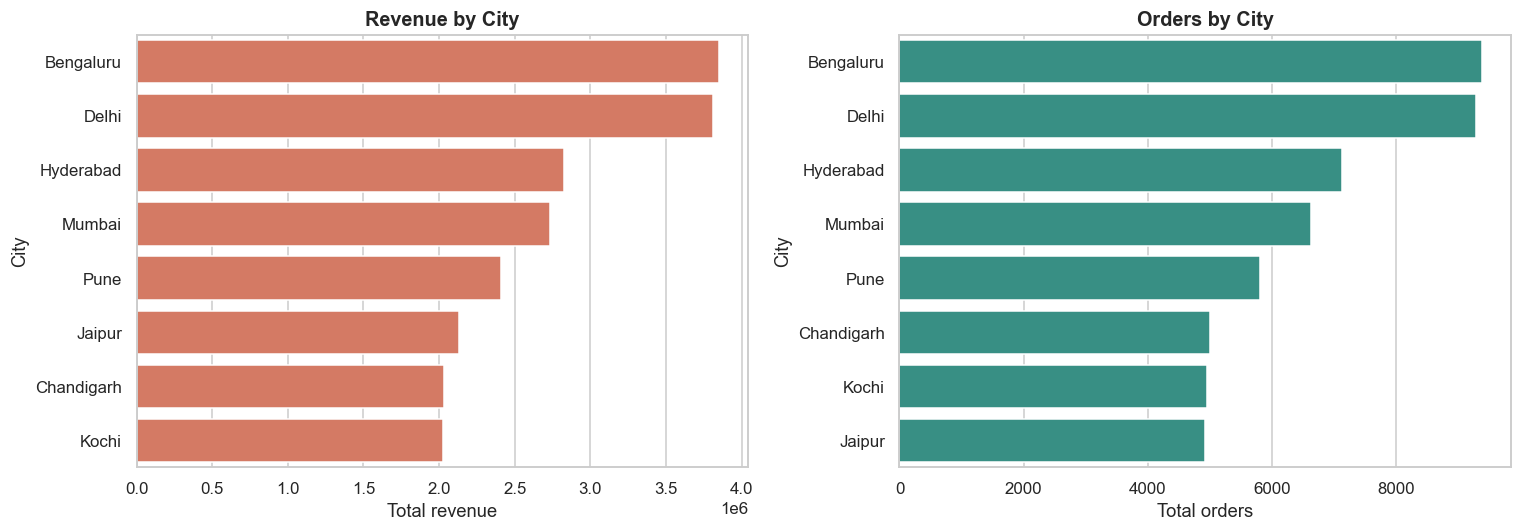

Interpretation: Bengaluru leads total revenue (3,851,959), while Bengaluru leads order volume (9,394).


In [15]:
city_summary = df.groupby('City')[['Orders', 'Revenue']].sum().sort_values('Revenue', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=city_summary.reset_index(), x='Revenue', y='City', ax=axes[0], color='#e76f51', order=city_summary.index)
sns.barplot(data=city_summary.reset_index(), x='Orders', y='City', ax=axes[1], color='#2a9d8f', order=city_summary.sort_values('Orders', ascending=False).index)
axes[0].set_title('Revenue by City'); axes[0].set_xlabel('Total revenue'); axes[0].set_ylabel('City')
axes[1].set_title('Orders by City'); axes[1].set_xlabel('Total orders'); axes[1].set_ylabel('City')
fig.tight_layout(); plt.show()
top_revenue_city = city_summary.index[0]
top_orders_city = city_summary['Orders'].idxmax()
print(f'Interpretation: {top_revenue_city} leads total revenue ({city_summary.loc[top_revenue_city, "Revenue"]:,.0f}), while {top_orders_city} leads order volume ({city_summary.loc[top_orders_city, "Orders"]:,.0f}).')

## 3. Cuisine performance

This bar chart ranks cuisines by average order value and total revenue to distinguish premium positioning from scale.

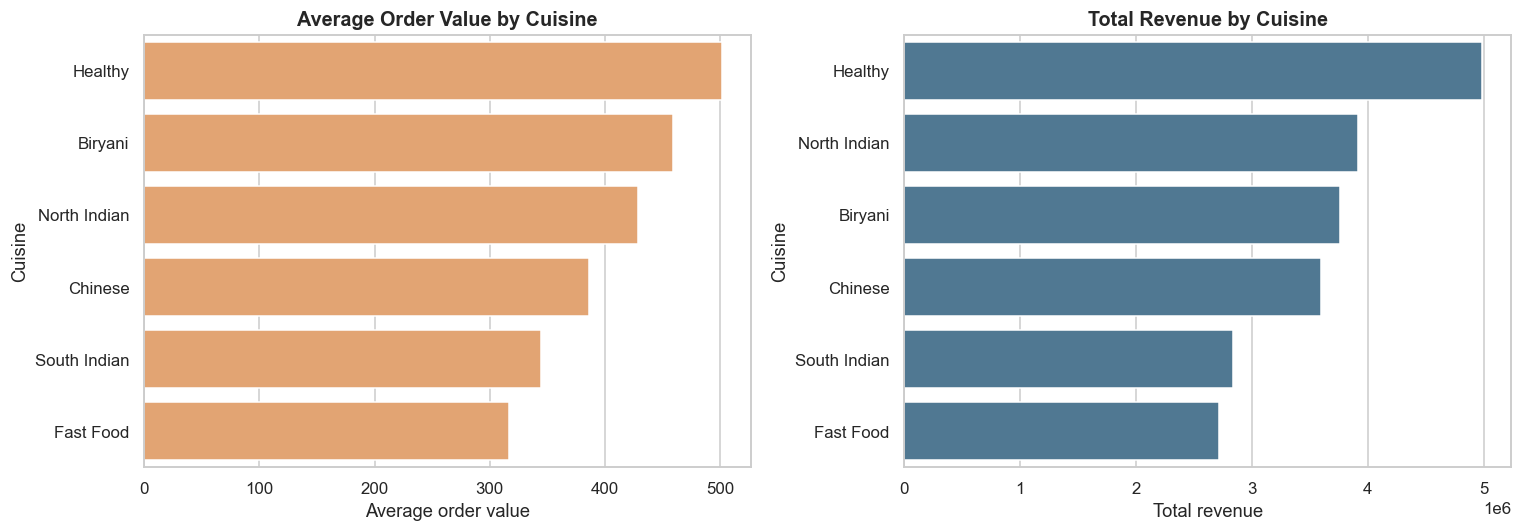

Interpretation: Healthy has the highest average order value (501.84), while Healthy contributes the most total revenue.


In [16]:
cuisine_summary = df.groupby('Cuisine').agg(Avg_Order_Value=('Average_Order_Value', 'mean'), Revenue=('Revenue', 'sum')).sort_values('Avg_Order_Value', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=cuisine_summary.reset_index(), x='Avg_Order_Value', y='Cuisine', ax=axes[0], color='#f4a261', order=cuisine_summary.index)
sns.barplot(data=cuisine_summary.reset_index().sort_values('Revenue', ascending=False), x='Revenue', y='Cuisine', ax=axes[1], color='#457b9d', order=cuisine_summary.sort_values('Revenue', ascending=False).index)
axes[0].set_title('Average Order Value by Cuisine'); axes[0].set_xlabel('Average order value'); axes[0].set_ylabel('Cuisine')
axes[1].set_title('Total Revenue by Cuisine'); axes[1].set_xlabel('Total revenue'); axes[1].set_ylabel('Cuisine')
fig.tight_layout(); plt.show()
top_value_cuisine = cuisine_summary.index[0]
top_revenue_cuisine = cuisine_summary['Revenue'].idxmax()
print(f'Interpretation: {top_value_cuisine} has the highest average order value ({cuisine_summary.loc[top_value_cuisine, "Avg_Order_Value"]:.2f}), while {top_revenue_cuisine} contributes the most total revenue.')

## 4. Marketing spend and revenue

A regression scatter plot tests whether higher marketing investment is associated with higher revenue.

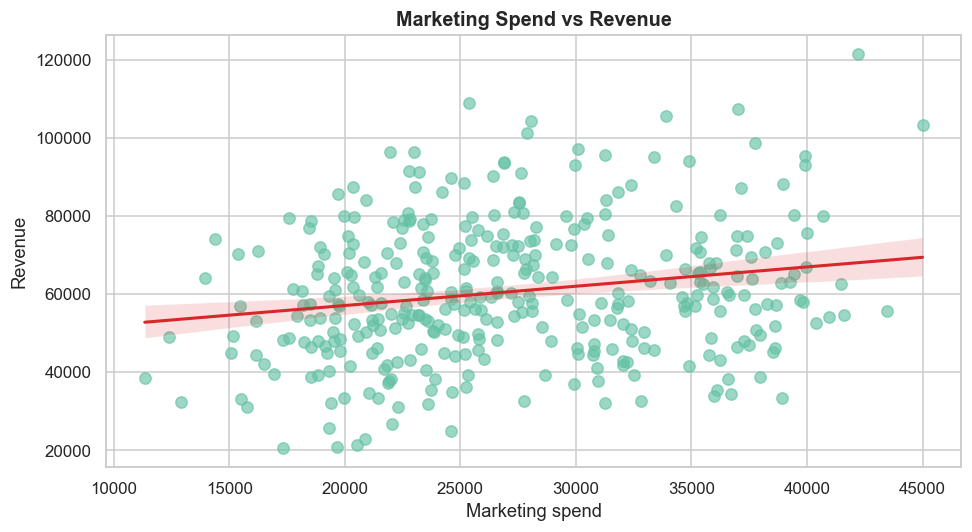

Interpretation: the Pearson correlation is 0.20, indicating a positive linear association between marketing spend and revenue. Correlation alone does not establish causation.


In [17]:
marketing_corr = df['Marketing_Spend'].corr(df['Revenue'])
fig, ax = plt.subplots(figsize=(9, 5))
sns.regplot(data=df, x='Marketing_Spend', y='Revenue', scatter_kws={'alpha': 0.65, 's': 55}, line_kws={'color': '#d62828', 'linewidth': 2}, ax=ax)
ax.set_title('Marketing Spend vs Revenue'); ax.set_xlabel('Marketing spend'); ax.set_ylabel('Revenue')
fig.tight_layout(); plt.show()
association = 'positive' if marketing_corr > 0 else 'negative'
print(f'Interpretation: the Pearson correlation is {marketing_corr:.2f}, indicating a {association} linear association between marketing spend and revenue. Correlation alone does not establish causation.')

## 5. Delivery time and customer ratings

This scatter plot examines whether slower deliveries correspond to lower customer ratings.

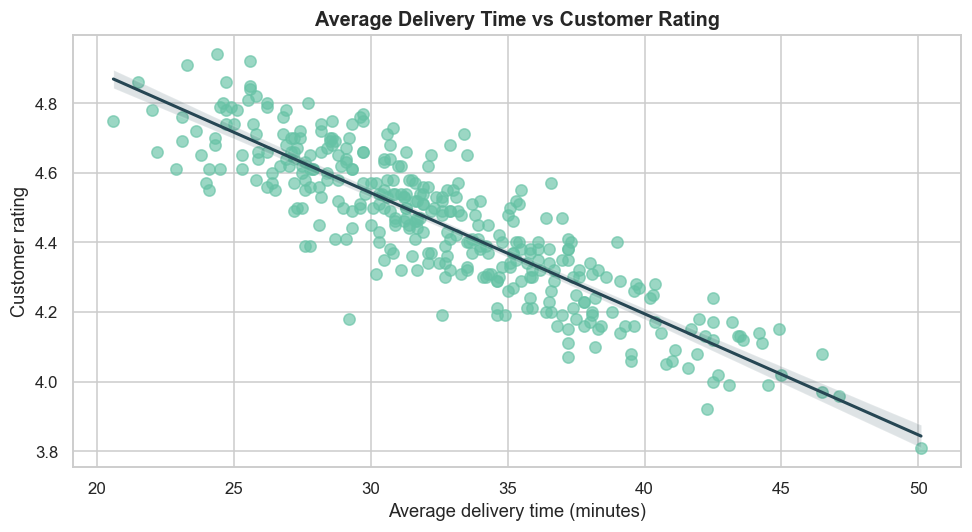

Interpretation: the Pearson correlation is -0.88; the relationship is negative, so delivery speed appears relevant to customer experience.


In [18]:
delivery_corr = df['Avg_Delivery_Minutes'].corr(df['Customer_Rating'])
fig, ax = plt.subplots(figsize=(9, 5))
sns.regplot(data=df, x='Avg_Delivery_Minutes', y='Customer_Rating', scatter_kws={'alpha': 0.65, 's': 55}, line_kws={'color': '#264653', 'linewidth': 2}, ax=ax)
ax.set_title('Average Delivery Time vs Customer Rating'); ax.set_xlabel('Average delivery time (minutes)'); ax.set_ylabel('Customer rating')
fig.tight_layout(); plt.show()
relationship = 'negative' if delivery_corr < 0 else 'positive'
print(f'Interpretation: the Pearson correlation is {delivery_corr:.2f}; the relationship is {relationship}, so delivery speed appears relevant to customer experience.')

## 6. Revenue distribution

The histogram shows the typical revenue range and whether unusually high or low observations are present.

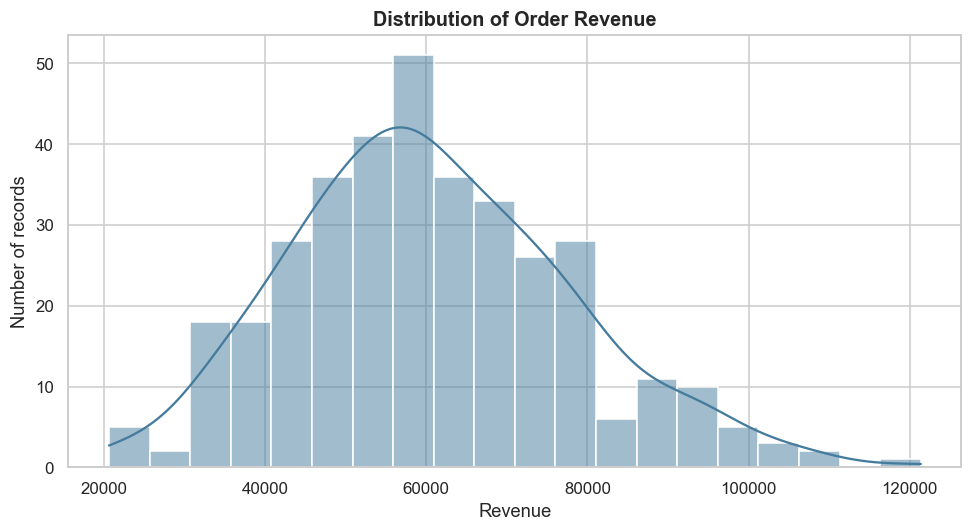

Interpretation: revenue has a mean of 60,591 and a median of 58,779; the difference indicates the distribution is influenced by higher-value orders.


In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x='Revenue', bins=20, kde=True, color='#457b9d', ax=ax)
ax.set_title('Distribution of Order Revenue'); ax.set_xlabel('Revenue'); ax.set_ylabel('Number of records')
fig.tight_layout(); plt.show()
revenue_mean = df['Revenue'].mean()
revenue_median = df['Revenue'].median()
print(f'Interpretation: revenue has a mean of {revenue_mean:,.0f} and a median of {revenue_median:,.0f}; the difference indicates the distribution is influenced by higher-value orders.')

## 7. Revenue by weather

The box plot compares revenue distributions under each weather condition, including variability and potential outliers.

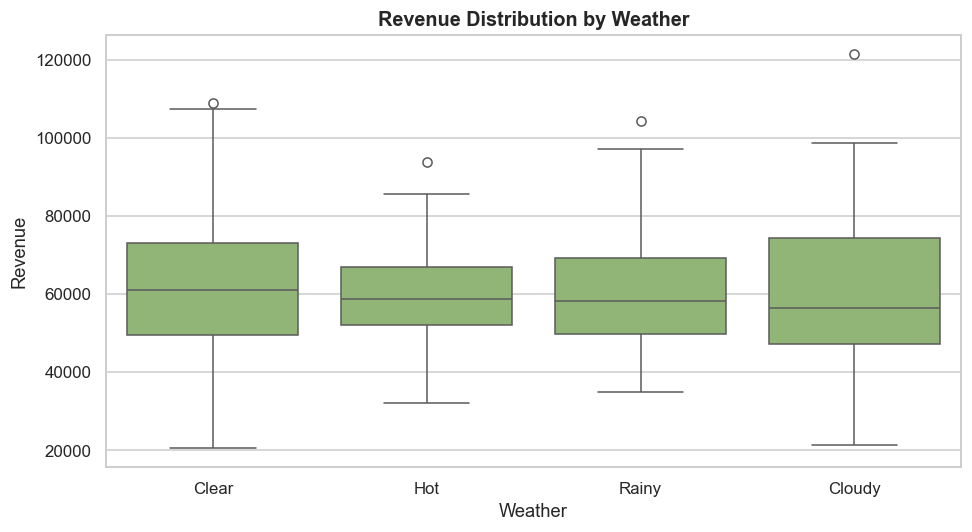

Interpretation: Clear has the highest median revenue (60,948), suggesting weather conditions may coincide with different demand or basket-value patterns.


In [20]:
weather_revenue = df.groupby('Weather', observed=False)['Revenue'].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Weather', y='Revenue', order=weather_revenue.index, color='#90be6d', ax=ax)
ax.set_title('Revenue Distribution by Weather'); ax.set_xlabel('Weather'); ax.set_ylabel('Revenue')
fig.tight_layout(); plt.show()
print(f'Interpretation: {weather_revenue.index[0]} has the highest median revenue ({weather_revenue.iloc[0]:,.0f}), suggesting weather conditions may coincide with different demand or basket-value patterns.')

## 8. Customer ratings by order channel

The violin plot shows the full rating distribution for App, Website, and Partner Platform orders.

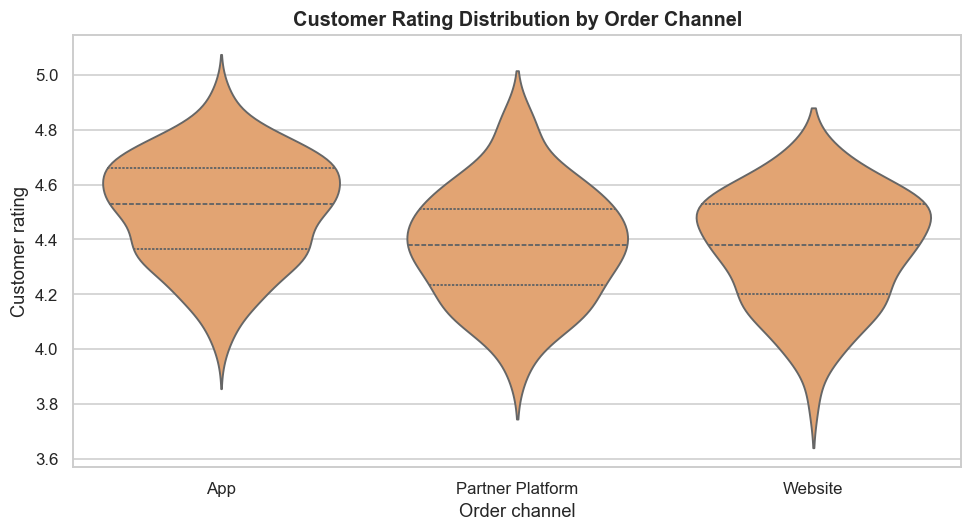

Interpretation: App has the highest mean rating (4.51); the violin widths show how ratings are distributed within each channel.


In [21]:
channel_rating = df.groupby('Order_Channel', observed=False)['Customer_Rating'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=df, x='Order_Channel', y='Customer_Rating', order=channel_rating.index, inner='quartile', color='#f4a261', ax=ax)
ax.set_title('Customer Rating Distribution by Order Channel'); ax.set_xlabel('Order channel'); ax.set_ylabel('Customer rating')
fig.tight_layout(); plt.show()
top_rating_channel = channel_rating.index[0]
print(f'Interpretation: {top_rating_channel} has the highest mean rating ({channel_rating.iloc[0]:.2f}); the violin widths show how ratings are distributed within each channel.')

## 9. Order mix by weather and channel

Count plots reveal how frequently records occur across operational conditions and ordering channels.

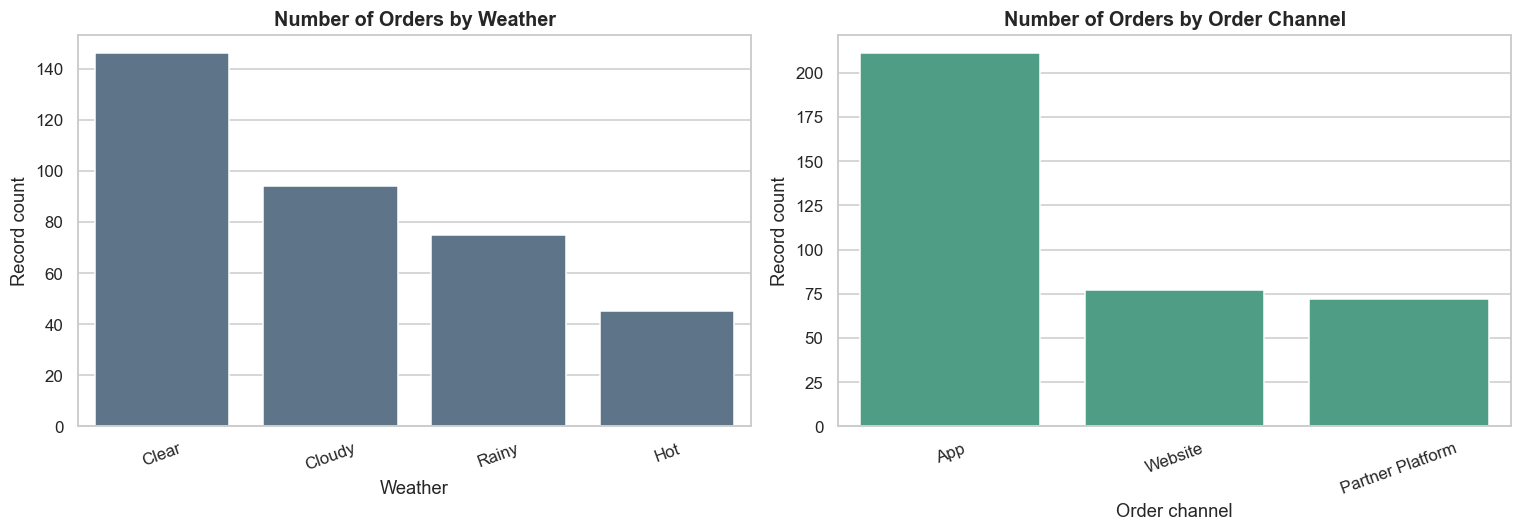

Interpretation: Clear is the most common recorded weather condition, and App is the most common channel in the dataset.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Weather', order=df['Weather'].value_counts().index, color='#577590', ax=axes[0])
sns.countplot(data=df, x='Order_Channel', order=df['Order_Channel'].value_counts().index, color='#43aa8b', ax=axes[1])
axes[0].set_title('Number of Orders by Weather'); axes[0].set_xlabel('Weather'); axes[0].set_ylabel('Record count')
axes[1].set_title('Number of Orders by Order Channel'); axes[1].set_xlabel('Order channel'); axes[1].set_ylabel('Record count')
axes[0].tick_params(axis='x', rotation=20); axes[1].tick_params(axis='x', rotation=20)
fig.tight_layout(); plt.show()
common_weather = df['Weather'].mode().iat[0]
common_channel = df['Order_Channel'].mode().iat[0]
print(f'Interpretation: {common_weather} is the most common recorded weather condition, and {common_channel} is the most common channel in the dataset.')

## 10. Correlation heatmap

The heatmap provides a compact view of linear relationships among the main numeric business metrics.

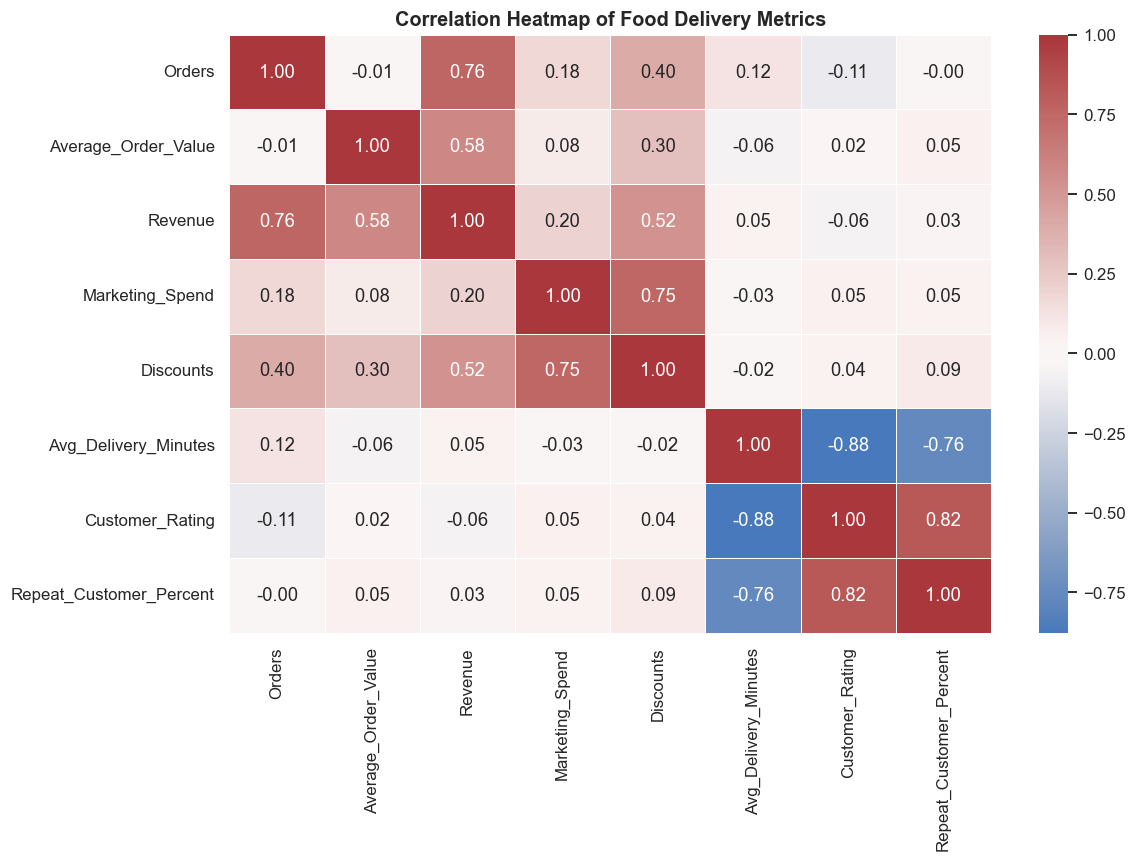

Interpretation: the strongest absolute correlation is between Customer_Rating and Avg_Delivery_Minutes (-0.88). This highlights the metric pair most closely associated in this sample.


In [23]:
numeric_columns = ['Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']
correlations = df[numeric_columns].corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(correlations, annot=True, fmt='.2f', cmap='vlag', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Food Delivery Metrics')
fig.tight_layout(); plt.show()
correlation_pairs = correlations.where(~np.eye(correlations.shape[0], dtype=bool)).stack().abs().sort_values(ascending=False)
strongest_pair = correlation_pairs.index[0]
print(f'Interpretation: the strongest absolute correlation is between {strongest_pair[0]} and {strongest_pair[1]} ({correlations.loc[strongest_pair[0], strongest_pair[1]]:.2f}). This highlights the metric pair most closely associated in this sample.')

## Conclusion: most important findings

The portfolio indicates that business performance varies across time, geography, cuisine, weather, and channel. Monthly totals identify the strongest demand and revenue periods; city and cuisine comparisons separate scale from average basket value. Marketing spend should be evaluated alongside its correlation with revenue rather than treated as proof of causation. Delivery time is especially important to monitor because its relationship with ratings directly reflects customer experience. Weather and channel distributions provide operational context for interpreting revenue and ratings. Finally, the heatmap helps prioritize the strongest relationships for deeper analysis, experimentation, and forecasting.

### Submission note

Place this notebook and `Day14_Food_Delivery_Visualization_Dataset.csv` in the public GitHub repository so that the notebook runs without changing the data source path, or replace `source_path` with a repository-relative path before publishing.